In [1]:
# Domain Adaptation Model Testing Notebook
# Load and test trained DA models with comprehensive evaluation

import sys
sys.path.append("..")
import os

import torch
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence, pack_sequence, pack_padded_sequence, unpack_sequence
import numpy as np
import yaml
import pandas as pd# 0. Experiment selection
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from tqdm import tqdm

from copy import deepcopy

from src.models.base_models import create_model
from src.models.domain_discriminator import DomainDiscriminator, create_da_model
from src.data.numu_dataset import NuMuDataset, create_numu_dataloader_from_ds

In [2]:
torch.cuda.is_available()

True

## Preparation

In [3]:
# Set up paths and experiment
EXPERIMENT_DIR = Path("../experiments/numu/da_numu_251112_small_smallddnoreg_aug_newlr")
DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

print(f"Testing experiment: {EXPERIMENT_DIR.name}")
print(f"Device: {DEVICE}")

SAVING_POSTFIX = "BigMCSample_EqualAtmAtsro"

report_dir = f"{EXPERIMENT_DIR}/report_{SAVING_POSTFIX}"
os.makedirs(report_dir, exist_ok=True)

fig_dir = f"{report_dir}/figures/"
os.makedirs(fig_dir, exist_ok=True)

# Load configuration files
config_path = EXPERIMENT_DIR / "da_config.yaml"
norm_config_path = EXPERIMENT_DIR / "normalization_config.yaml"

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

with open(norm_config_path, 'r') as f:
    normalization_config = yaml.safe_load(f)
    
# Load models
## Load trained models from best checkpoint
checkpoint_path = EXPERIMENT_DIR / "best_da_model.pth"
print(f"Loading checkpoint from: {checkpoint_path}")
checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
## Create and load base model
model = create_model(config['model'])
model.load_state_dict(checkpoint['base_model_state_dict'])
model.to(DEVICE)
model.eval()
## Create and load domain discriminator
feature_dim = config['model']['feature_extractor']['d_model']
domain_discriminator = DomainDiscriminator(
    input_dim=feature_dim,
    **config['domain_adaptation']['domain_discriminator']
)
domain_discriminator.load_state_dict(checkpoint['domain_discriminator_state_dict'])
domain_discriminator.to(DEVICE)
domain_discriminator.eval()

Testing experiment: da_numu_251112_small_smallddnoreg_aug_newlr
Device: cuda:1
Loading checkpoint from: ../experiments/numu/da_numu_251112_small_smallddnoreg_aug_newlr/best_da_model.pth


DomainDiscriminator(
  (gradient_reversal): GradientReversalLayer()
  (discriminator): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [4]:
torch.cuda.is_available()

True

In [3]:
# Load datasets

# MC
## Create test dataset (using source domain for classification evaluation)
source_config = config['data']['source_domain']
train_events_per_particle = config['data']['source_domain']['events_per_particle']
## Use validation portion of source data for testing (events model hasn't seen)
mc_dataset = NuMuDataset(
    h5_path=source_config['h5_path'],
    events_per_particle={'muatm_2020': 500_000, 'nue2_2020': 250_000, 'nuatm_2020': 250_000},  # Test portion
    particle_types=source_config['particle_types'],
    neutrino_types=source_config['neutrino_types'],
    max_hits=config['data']['max_hits'],
    sampling_config={
        'muatm_2020': {'mode': 'range', 'start_event': train_events_per_particle['muatm_2020']},
        'nue2_2020': {'mode': 'range', 'start_event': train_events_per_particle['nue2_2020']},
        'nuatm_2020': {'mode': 'range', 'start_event': train_events_per_particle['nuatm_2020']}
        },
    device=DEVICE,
    shuffle_events=False
)
## Create test dataloader
mc_dataloader = create_numu_dataloader_from_ds(
    dataset=mc_dataset,
    batch_size=256,
    normalization_config=normalization_config,
    augmentation_config=None,  # No augmentation for testing
    num_workers=0,
    shuffle=True,
    shuffle_batch=False
)
print(f"Test dataloader created:")
print(f"- Batch size: {mc_dataloader.batch_size}")
print(f"- Number of batches: {len(mc_dataloader)}")
print(f"- Total events: {len(mc_dataset)}")
print(f"- Normalization: {normalization_config['feature_names']}")
print(f"- Means: {normalization_config['means']}")
print(f"- Stds: {normalization_config['stds']}")

# EXP
## Create a sample of target domain data for domain discrimination test
target_config = config['data']['target_domain']
target_dataset = NuMuDataset(
    h5_path=target_config['h5_path'],
    particle_types=target_config['particle_types'],
    neutrino_types=target_config.get('neutrino_types', []),
    sampling_config={
        'exp': {
            'mode': 'range', 'start_event': target_config['events_per_particle']['exp']
                }},
    events_per_particle={'exp': 500_000},  # Small sample
    max_hits=config['data']['max_hits'],
    device=DEVICE,
    shuffle_events=False
)
target_dataloader = create_numu_dataloader_from_ds(
    dataset=target_dataset,
    batch_size=256,
    normalization_config=normalization_config,
    shuffle_batch=False,
    augmentation_config=None,
    num_workers=0,
    shuffle=False
)

print(f"Target Test dataloader created:")
print(f"- Batch size: {target_dataloader.batch_size}")
print(f"- Number of batches: {len(target_dataloader)}")
print(f"- Total events: {len(target_dataset)}")

NameError: name 'config' is not defined

In [ ]:
# Make preds and Collect stats

# MC
mc_raw_data = []
mc_predictions = []
mc_probabilities = []
mc_labels = []
mc_features = []
mc_magic_numbers = []
mc_channels_ids = []
mc_dd_probs = []
batch_num = 0
with torch.no_grad():
    for batch in tqdm(mc_dataloader, miniters=50, desc='For MC dataset'):
        # Get feature representations and predictions
        feature_repr = model.get_feature_representation(batch)
        logits = model.classifier(feature_repr)
        dd_logits = domain_discriminator(feature_repr)
        probabilities_batch = torch.sigmoid(logits)
        dd_probs_batch = torch.sigmoid(dd_logits)
        predictions_batch = (probabilities_batch > 0.5).float()
        
        # Store results
        mc_features.append(feature_repr.cpu())
        mc_predictions.append(predictions_batch.cpu())
        mc_probabilities.append(probabilities_batch.cpu())
        mc_dd_probs.append(dd_probs_batch.cpu())
        mc_labels.append(batch['labels'].cpu())
        mc_magic_numbers.extend(batch['magic_numbers'])
        mc_channels_ids.extend(batch['channels_ids'])
        
        # Raw features
        packed_seq_raw_data_batch = pack_padded_sequence(
            batch['features'].cpu(), batch['lengths'].cpu(), 
            batch_first=True, enforce_sorted=False
            )
        mc_raw_data.extend([t.numpy() for t in unpack_sequence(packed_seq_raw_data_batch)])
        if batch_num>500:
            break
        batch_num += 1
## Concatenate all results
mc_features = torch.cat(mc_features, dim=0).numpy()
mc_predictions = torch.cat(mc_predictions, dim=0).numpy().flatten()
mc_probabilities = torch.cat(mc_probabilities, dim=0).numpy().flatten()
mc_labels = torch.cat(mc_labels, dim=0).numpy().flatten()
mc_dd_probs = torch.cat(mc_dd_probs, dim=0).numpy().flatten()


# EXP
exp_raw_data = []
exp_predictions = []
exp_probabilities = []
exp_features = []
exp_channels_ids = []
exp_dd_probs = []
print()
batch_num = 0
with torch.no_grad():
    for batch in tqdm(target_dataloader, miniters=50, desc="For EXP (target) dataset"):
        # Get feature representations and predictions
        feature_repr = model.get_feature_representation(batch)
        logits = model.classifier(feature_repr)
        dd_logits = domain_discriminator(feature_repr)
        probabilities_batch = torch.sigmoid(logits)
        dd_probs_batch = torch.sigmoid(dd_logits)
        predictions_batch = (probabilities_batch > 0.5).float()
        
        # Store results
        exp_features.append(feature_repr.cpu())
        exp_predictions.append(predictions_batch.cpu())
        exp_probabilities.append(probabilities_batch.cpu())
        exp_dd_probs.append(dd_probs_batch.cpu())
        exp_channels_ids.extend(batch['channels_ids'])
        
        # Raw features
        packed_seq_raw_data_batch = pack_padded_sequence(
            batch['features'].cpu(), batch['lengths'].cpu(), 
            batch_first=True, enforce_sorted=False
            )
        exp_raw_data.extend([t.numpy() for t in unpack_sequence(packed_seq_raw_data_batch)])
        # if batch_num>500:
        #     break
        batch_num += 1
## Concatenate all results
exp_features = torch.cat(exp_features, dim=0).numpy()
exp_predictions = torch.cat(exp_predictions, dim=0).numpy().flatten()
exp_probabilities = torch.cat(exp_probabilities, dim=0).numpy().flatten()
exp_dd_probs = torch.cat(exp_dd_probs, dim=0).numpy().flatten()

For MC dataset:   0%|          | 0/3907 [00:00<?, ?it/s]/home/albert/miniconda3/envs/baikal25/lib/python3.10/site-packages/torch/nn/modules/transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(
For MC dataset:  13%|█▎        | 501/3907 [00:12<01:27, 38.83it/s]


For EXP (target) dataset:  37%|███▋      | 501/1368 [00:12<00:22, 38.59it/s]


## Reco data loading

In [1]:
import h5py
import uproot as ur
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('../../Baikal-ML')

from data.root_extractor.internal_root_paths import ExpRecoRootPaths
from data.root_extractor.main import RootFileReader

In [2]:
# data
names = ['2020/2020_cl3_run124_scl_DATA2020',
        '2020/2020_cl3_run123_scl_DATA2020',
        '2020/2020_cl3_run126_scl_DATA2020',
        '2020/2020_cl3_run128_scl_DATA2020',
        '2020/2020_cl3_run127_scl_DATA2020',
        '2020/2020_cl3_run120_scl_DATA2020',
        '2020/2020_cl3_run121_scl_nu_DATA2020',
        '2020/2020_cl3_run129_scl_DATA2020',
        '2020/2020_cl3_run125_scl_DATA2020',
        '2020/2020_cl3_run122_scl_DATA2020',
        '2020/2020_cl3_run121_scl_DATA2020']
reco_paths = [f"/net/62/home3/ivkhar/Baikal/data/initial_data/exp_data/{name}.root" for name in names]

norm_params = {
    'means': [2., 0., 0., 0., 0.],
    'stds': [60., 1370., 40., 40., 150.],
    'feature_names': ['amplitude', 'time', 'x', 'y', 'z']
}

In [3]:
cl3_centers = [-278.94, -97.17, 362.4]    

pulses_df = []
om_coords = []
events_df = []
for i, path in enumerate(reco_paths):
    with RootFileReader(path, ExpRecoRootPaths(), prefix=f"{i}_") as rr:
        events_df.append(rr.read_events_as_df().to_pandas())
        pulses_df.append(rr.read_pulses_as_df().to_pandas())
        #muons = rr.read_muons_as_df()
        om_coords.append(rr.read_OM_coords().to_pandas())
pulses_df_pd = pd.concat(pulses_df, axis=0)
om_coords_pd = pd.concat(om_coords, axis=0)

exp_reco_df0 = pulses_df_pd.merge(om_coords_pd[['X','Y','Z','PulsesChID','ev_id']], how='left', on=['ev_id', 'PulsesChID']).dropna()
# Centering cluster
exp_reco_df0['X'] = exp_reco_df0['X'] - cl3_centers[0]
exp_reco_df0['Y'] = exp_reco_df0['Y'] - cl3_centers[1]
exp_reco_df0['Z'] = exp_reco_df0['Z'] - cl3_centers[2]
# Center times
times_centers = exp_reco_df0[['ev_id', 'PulsesTime']].groupby('ev_id').agg('mean').rename(columns={'PulsesTime': 't_center'})
exp_reco_df0 = exp_reco_df0.merge(times_centers, how='left', on='ev_id')
# Norm data
exp_reco_df0['PulsesTime'] = exp_reco_df0['PulsesTime'] - exp_reco_df0['t_center']
for i, col in enumerate(['PulsesAmpl', 'PulsesTime', 'X', 'Y', 'Z']):
    exp_reco_df0[col] = (exp_reco_df0[col] - norm_params['means'][i])/norm_params['stds'][i]
# Agg data
exp_reco_df0['input_features'] = exp_reco_df0[['PulsesAmpl', 'PulsesTime', 'X', 'Y', 'Z']].agg(np.array, axis=1)

In [4]:
events_df_pd = pd.concat(events_df)
events_df_pd.head(10)

,PulsesN,fThetaRec,fThetaErr,fNHits,fPhiRec,fPhiErr,fPathLength,ev_id
0,0,0.000000,0.000000,0,0.000000,0.000000,-1.000000,0_0
1,85,146.612396,0.309069,14,77.797752,0.778779,277.352628,0_1
2,63,165.015274,0.537672,8,32.558414,1.766443,405.324353,0_2
3,107,135.268509,0.422907,14,249.429947,0.423616,221.765027,0_3
4,63,137.906265,0.527256,8,294.018463,1.064957,160.579079,0_4
5,73,147.086517,0.522435,8,297.177124,0.675667,276.067514,0_5
6,81,138.140137,0.432777,7,297.601898,2.309916,208.823570,0_6
7,83,125.861053,0.600778,12,322.539490,0.699609,198.398354,0_7
8,79,161.721710,1.271694,7,2.661189,1.954410,467.569514,0_8
9,103,149.459076,0.251099,17,94.428749,0.497113,262.834743,0_9


In [24]:
with ur.open(path) as rf:
    all_keys = rf['Events;1'].keys()
    print([k for k in all_keys if 'fNHits' in k])

['BRecoMuon./BRecoMuon.fNHitsInit', 'BRecoMuon./BRecoMuon.fNHits', 'BRecoMuon./BRecoMuon.fNHitsRecoll', 'BRecoMuon./BRecoMuon.fNHits_clHM', 'BRecoMuon./BRecoMuon.fNHits_clLM', 'BRecoMuon./BRecoMuon.fNHits_22m', 'BRecoMuon./BRecoMuon.fNHits_30m']


In [60]:
exp_reco_df = exp_reco_df0[['ev_id', 'SignalFlg', 'input_features']].groupby('ev_id').aggregate(
    {'SignalFlg': 'sum', 'input_features': list}
    ).rename(columns={'SignalFlg': 'sig_hits_num'})
# Sort times within 1 event
exp_reco_df['input_features'] = exp_reco_df['input_features'].apply(lambda x: sorted(x, key=lambda arr: arr[1]))

In [63]:
start = 0
step = 256
reco_raw_data = []
reco_predictions = []
reco_probabilities = []
reco_features = []
reco_channels_ids = []
reco_dd_probs = []
reco_sig_hits_num = []
batch_num = 0
with torch.no_grad():
    while start<len(exp_reco_df):
        batch_data = exp_reco_df['input_features'].iloc[start:start+step]
        exp_raw_data.extend(batch_data)
        lengths = torch.tensor([len(arr) for arr in batch_data], dtype=int, device=DEVICE)
        batch_data = [torch.tensor(arr, device=DEVICE, dtype=torch.float32) for arr in batch_data]
        reco_sig_hits_num.extend(exp_reco_df['sig_hits_num'].iloc[start:start+step])
        mask = pad_sequence([torch.ones(l, dtype=bool, device=DEVICE) for l in lengths], batch_first=True)
        data_pad = pad_sequence(batch_data, batch_first=True)
        batch = {}
        batch['features'] = data_pad
        batch['mask'] = mask
        batch['lengths'] = lengths
        
        feature_repr = model.get_feature_representation(batch)
        logits = model.classifier(feature_repr)
        dd_logits = domain_discriminator(feature_repr)
        probabilities_batch = torch.sigmoid(logits)
        dd_probs_batch = torch.sigmoid(dd_logits)
        predictions_batch = (probabilities_batch > 0.5).float()
        
        # Store results
        reco_features.append(feature_repr.cpu())
        reco_predictions.append(predictions_batch.cpu())
        reco_probabilities.append(probabilities_batch.cpu())
        reco_dd_probs.append(dd_probs_batch.cpu())

        # if batch_num>500:
        #     break
        batch_num += 1
        start += step

## Concatenate all results
reco_features = torch.cat(reco_features, dim=0).numpy()
reco_predictions = torch.cat(reco_predictions, dim=0).numpy().flatten()
reco_probabilities = torch.cat(reco_probabilities, dim=0).numpy().flatten()
reco_dd_probs = torch.cat(reco_dd_probs, dim=0).numpy().flatten()
reco_sig_hits_num = np.array(reco_sig_hits_num)

# Plots

In [80]:
mc_signal_hit_nums = np.asarray([(numbers!=0).sum() for numbers in mc_magic_numbers])

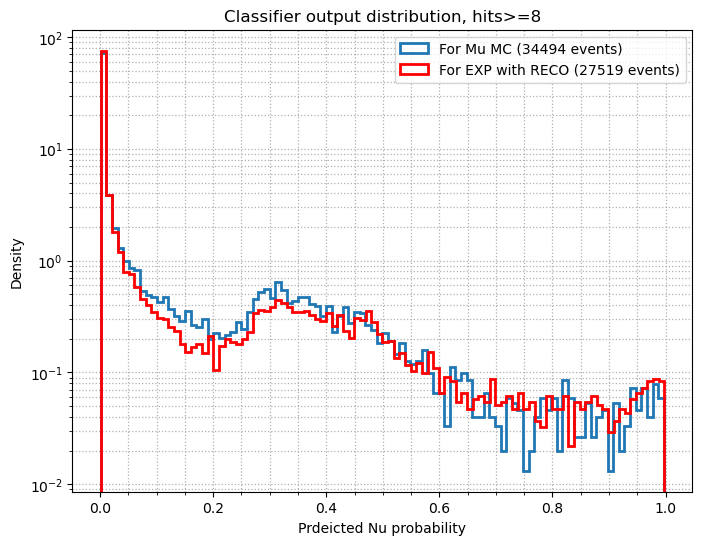

In [83]:
# Pmunu EXP VS MC
mc_mask = np.ones(len(mc_probabilities), dtype=bool) & (mc_signal_hit_nums>=8) #& (mc_qgt10_num>=2) & (mc_qgt20_num>=1)
labels_masked, mc_probabilities_masked = mc_labels[mc_mask], mc_probabilities[mc_mask]

exp_mask = np.ones(len(exp_probabilities), dtype=bool) #& (exp_qgt10_num>=2) & (exp_qgt20_num>=1)
exp_probas_masked = exp_probabilities[exp_mask]

reco_mask = np.ones(len(reco_probabilities), dtype=bool) & (reco_sig_hits_num>=8) #& (reco_qgt20_num>=1)
reco_probas_masked = reco_probabilities[reco_mask]

plt.figure(figsize=(8,6))
plt.hist(mc_probabilities_masked[~labels_masked], bins=100, density=True, log=True, histtype='step', lw=2., label=f'For Mu MC ({sum(mc_mask)} events)')
#plt.hist(exp_probas_masked, color='coral', bins=100, density=True, log=True, histtype='step', lw=2., label=f'For EXP ({sum(exp_mask)} events)')
plt.hist(reco_probas_masked, color='red', bins=100, density=True, log=True, histtype='step', lw=2., label=f'For EXP with RECO ({sum(reco_mask)} events)')
plt.title("Classifier output distribution, hits>=8")
plt.legend()
plt.grid(which='both', ls=':', lw=0.9)
plt.xlabel("Prdeicted Nu probability")
plt.ylabel("Density")
plt.minorticks_on()
plt.show()
plt.close()